## Setup

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/baikalseal/italian-finnish-data/finnish_validation_dataset.json
/kaggle/input/datasets/baikalseal/italian-finnish-data/italian_test_dataset.json
/kaggle/input/datasets/baikalseal/italian-finnish-data/italian_train_dataset.json
/kaggle/input/datasets/baikalseal/italian-finnish-data/italian_validation_dataset.json
/kaggle/input/datasets/baikalseal/italian-finnish-data/finnish_test_dataset.json
/kaggle/input/datasets/baikalseal/italian-finnish-data/finnish_train_dataset.json


In [2]:
%pip install transformer_lens

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# restarting kaggle notebook without clearing cell outputs
os._exit(0)

In [34]:
import json
import math
import random
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from transformer_lens import HookedTransformer, ActivationCache

In [4]:
%cd /kaggle/input/datasets/baikalseal/italian-finnish-data

/kaggle/input/datasets/baikalseal/italian-finnish-data


In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

set_seed(42)

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = HookedTransformer.from_pretrained(
    "qwen3-1.7b",
    center_unembed=True,
    center_writing_weights=False,
    fold_ln=False,
    fold_value_biases=False,
    dtype="bfloat16",
    trust_remote_code=True,
).to(device)
print("Model loaded successfully.")

Using device: cuda


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Loaded pretrained model qwen3-1.7b into HookedTransformer
Moving model to device:  cuda
Model loaded successfully.


### Some helpful functions

In [7]:
def get_batched_dataset(model, dataset, batch_size=8):
    items = list(dataset.values())
    num_total_samples = len(items)
    num_batches = math.floor(num_total_samples / batch_size)

    batches = []

    for i in range(num_batches):
        batch_items = items[i * batch_size : (i + 1) * batch_size]

        prefixes = [item["prefix"] for item in batch_items]
        prefix_tokens = model.to_tokens(prefixes)

        answer_token_lists = []
        for item in batch_items:
            correct_ids = model.to_tokens(" " + item["correct_verb"], prepend_bos=False)[0]
            incorrect_ids = model.to_tokens(" " + item["incorrect_verb"], prepend_bos=False)[0]

            answer_token_lists.append((correct_ids, incorrect_ids))

        batches.append({
            "prefix_tokens": prefix_tokens,
            "answer_token_lists": answer_token_lists,
            "metadata": batch_items
        })

    return batches

In [8]:
def get_subject_indices(model, prefix, subject):
    """
    Finds exactly which token indices correspond to the subject string.
    """
    full_tokens = model.to_str_tokens(prefix)

    subj_tokens = model.to_str_tokens(subject)

    if full_tokens[0].startswith("<"):
        full_tokens = full_tokens[1:]
    if subj_tokens[0].startswith("<"):
        subj_tokens = subj_tokens[1:]

    subj_len = len(subj_tokens)
    for i in range(len(full_tokens) - subj_len + 1):
        if full_tokens[i : i + subj_len] == subj_tokens:
            return list(range(i, i + subj_len))

    return []

In [9]:
def extract_subj(item):
    """Helps to get subject string based on language"""
    prefix = item['prefix']
    return prefix.split(" che")[0] if item['language'] == "italian" else prefix.split(" joka")[0].split(" jotka")[0]

In [11]:
def get_clean_and_corr_batches(model, dataset_dict, batch_size=8):
    """Splits batches for clean and corrupted runs"""
    items = list(dataset_dict.values())

    grouped = {}
    for item in items:
        grouped.setdefault(item["item_id"], []).append(item)

    clean_items = []
    corr_items = []

    for i, (item_id, pair) in enumerate(grouped.items()):
        if len(pair) == 2:
            p1, p2 = pair

            if item_id % 2 == 0:
                src = p1 if p1["subject_number"] == "plural" else p2
                base = p1 if p1["subject_number"] == "singular" else p2
            else:
                src = p1 if p1["subject_number"] == "singular" else p2
                base = p1 if p1["subject_number"] == "plural" else p2

            clean_items.append(src)
            corr_items.append(base)

    clean_batches = get_batched_dataset(model, {str(i): x for i, x in enumerate(clean_items)}, batch_size)
    corr_batches = get_batched_dataset(model, {str(i): x for i, x in enumerate(corr_items)}, batch_size)

    return clean_batches, corr_batches

In [10]:
def get_logit_diff(logits, answer_token_lists, mean=True):
    """Calculates logit difference"""
    if logits.dim() == 3:
        logits = logits[:, -1, :]

    diffs = []
    for i, (corr_ids, incorr_ids) in enumerate(answer_token_lists):
        corr_logit = logits[i, corr_ids].mean()
        incorr_logit = logits[i, incorr_ids].mean()
        diffs.append(corr_logit - incorr_logit)

    diffs = torch.stack(diffs)
    return diffs.mean() if mean else diffs

### Loading datasets

In [18]:
with open("italian_train_dataset.json", "r", encoding="utf-8") as f:
    it_train_json = json.load(f)
with open("finnish_train_dataset.json", "r", encoding="utf-8") as f:
    fi_train_json = json.load(f)

it_train_batches = get_batched_dataset(model, it_train_json)[:175]
fi_train_batches = get_batched_dataset(model, fi_train_json)[:175]

In [19]:
with open("italian_test_dataset.json", "r", encoding="utf-8") as f:
    it_test_json = json.load(f)
with open("finnish_test_dataset.json", "r", encoding="utf-8") as f:
    fi_test_json = json.load(f)

it_test_batches = get_batched_dataset(model, it_test_json)[:60]
fi_test_batches = get_batched_dataset(model, fi_test_json)[:60]

In [78]:
it_clean_batches, it_corr_batches = get_clean_and_corr_batches(model, it_test_json)
fi_clean_batches, fi_corr_batches = get_clean_and_corr_batches(model, fi_test_json)

## Linear Steering

In [24]:
class LinearSteeringIntervention:
	def __init__(self, model, layer, device="cuda"):
		self.model = model
		self.layer = layer
		self.device = device
		self.hook_name = f"blocks.{layer}.hook_resid_post"
		self.direction = None   # future learned vector
		self.clf = None
		self.scaler = StandardScaler()

	def collect_activations(self, batches, extract_subj_fn, get_indices_fn):
		"""
		Collects activations from the residual stream at the subject's position
		"""
		all_activations = []
		all_labels = []

		for batch in batches:
			with torch.no_grad():
				_, cache = self.model.run_with_cache(
					batch['prefix_tokens'],
					names_filter=lambda name: name == self.hook_name
				)

				for b_idx in range(len(batch['metadata'])):
					item = batch['metadata'][b_idx]
					subj_str = extract_subj_fn(item)
					indices = get_indices_fn(self.model, item['prefix'], subj_str)

					if indices:
						activation = cache[self.hook_name][b_idx, indices[-1], :].detach().cpu().float()
						all_activations.append(activation)
						label = 1 if item['subject_number'] == 'singular' else 0
						all_labels.append(label)

		return np.array(all_activations), np.array(all_labels)

	def train_direction(self, activations, labels, C=0.01):
		"""
		Logistic regression with L2-regularization
		"""
		self.scaler = StandardScaler()
		X_scaled = self.scaler.fit_transform(activations)

		self.clf = LogisticRegression(max_iter=1000, C=C, penalty='l2', random_state=42)

		self.clf.fit(X_scaled, labels)
		raw_vec = self.clf.coef_[0]
		self.direction = torch.tensor(
			raw_vec / np.linalg.norm(raw_vec), dtype=torch.float32
		).to(self.device)

		print(f"Direction learned. Accuracy: {self.clf.score(X_scaled, labels):.2f}")
		return self.direction
	
	def predict_on_activations(self, activations, labels):
		"""
		Tests the classifier on second language activations
		"""
		X_scaled = self.scaler.transform(activations)
		acc = self.clf.score(X_scaled, labels)
		return acc

	def steering_hook(self, activation, hook, coeff=1.0, mean=False):
		"""
		Adds a vector to the last token
		"""
		if self.direction is None:
			raise ValueError()

		with torch.no_grad():
			norm = activation[:, -1, :].norm(dim=-1, keepdim=True)
			activation[:, -1, :] += coeff * self.direction * norm
		
		return activation

	def run_steered_logit_diff(self, batch, get_logit_diff_fn, coeff=1.0, mean=False):
		"""
		Runs the model with intervention and calculates the logit difference
		"""
		hook_fn = partial(self.steering_hook, coeff=coeff)

		steered_logits = self.model.run_with_hooks(
			batch['prefix_tokens'],
			fwd_hooks=[(self.hook_name, hook_fn)]
		)

		return get_logit_diff_fn(steered_logits, batch['answer_token_lists'], mean=mean)

In [25]:
def run_grid_search(model, layers, coeffs, train_batches, eval_batches):
    """"Runs grid search for linear steering"""
    grid_results = []
    interventions_dict = {}

    for layer in layers:
        intervention = LinearSteeringIntervention(model, layer=layer)

        acts, labels = intervention.collect_activations(train_batches, extract_subj, get_subject_indices)
        intervention.train_direction(acts, labels)
        
        interventions_dict[layer] = intervention
        
        print(f"\nLayer {layer+1}")
        print(f"{'Coeff':<8} | {'Singular LD':<12} | {'Plural LD':<12}")

        for c in coeffs:
            all_s_changes = []
            all_p_changes = []

            for batch in eval_batches:
                singular_idx = [i for i, m in enumerate(batch['metadata']) if m['subject_number'] == 'singular']
                plural_idx = [i for i, m in enumerate(batch['metadata']) if m['subject_number'] == 'plural']

                with torch.no_grad():
                    ld_before = get_logit_diff(model(batch['prefix_tokens']), batch['answer_token_lists'], mean=False)
                    ld_after = intervention.run_steered_logit_diff(
                        batch, coeff=c, get_logit_diff_fn=get_logit_diff, mean=False
                    ).to(ld_before.device)

                changes = ld_after - ld_before
                
                if singular_idx: all_s_changes.append(changes[singular_idx].cpu())
                if plural_idx: all_p_changes.append(changes[plural_idx].cpu())

            s_mean = torch.cat(all_s_changes).mean().item() if all_s_changes else 0
            p_mean = torch.cat(all_p_changes).mean().item() if all_p_changes else 0

            grid_results.append({
                'layer': layer, 'coeff': c,
                's_change': s_mean, 'p_change': p_mean
            })
            print(f"{c:<8} | {s_mean:<+12.3f} | {p_mean:<+12.3f}")
        
        print()

    return grid_results, interventions_dict

In [26]:
it_layers = list(range(19, 28))
it_coeffs = [0.1, 0.2, 0.5]

it_grid, it_interventions = run_grid_search(
    model,
    it_layers,
    it_coeffs,
    it_train_batches,
    it_test_batches
)

Direction learned. Accuracy: 1.00

Layer 20
Coeff    | Singular LD  | Plural LD   
0.1      | +0.057       | -0.072      
0.2      | +0.088       | -0.146      
0.5      | +0.053       | -0.326      

Direction learned. Accuracy: 1.00

Layer 21
Coeff    | Singular LD  | Plural LD   
0.1      | +0.085       | -0.121      
0.2      | +0.155       | -0.252      
0.5      | +0.106       | -0.465      

Direction learned. Accuracy: 1.00

Layer 22
Coeff    | Singular LD  | Plural LD   
0.1      | +0.185       | -0.326      
0.2      | +0.232       | -0.562      
0.5      | +0.176       | -0.930      

Direction learned. Accuracy: 1.00

Layer 23
Coeff    | Singular LD  | Plural LD   
0.1      | +0.287       | -0.504      
0.2      | +0.291       | -0.770      
0.5      | -0.352       | -0.516      

Direction learned. Accuracy: 1.00

Layer 24
Coeff    | Singular LD  | Plural LD   
0.1      | +0.672       | -0.859      
0.2      | +0.984       | -1.430      
0.5      | +0.041       | -1.125   

In [28]:
fi_layers = list(range(19, 28))
fi_coeffs = [0.1, 0.2, 0.5]

fi_grid, fi_interventions = run_grid_search(
    model,
    fi_layers,
    fi_coeffs,
    fi_train_batches,
    fi_test_batches
)

Direction learned. Accuracy: 1.00

Layer 20
Coeff    | Singular LD  | Plural LD   
0.1      | +0.149       | -0.107      
0.2      | +0.243       | -0.159      
0.5      | +0.281       | -0.162      

Direction learned. Accuracy: 1.00

Layer 21
Coeff    | Singular LD  | Plural LD   
0.1      | +0.198       | -0.092      
0.2      | +0.320       | -0.112      
0.5      | +0.229       | +0.233      

Direction learned. Accuracy: 1.00

Layer 22
Coeff    | Singular LD  | Plural LD   
0.1      | +0.183       | -0.162      
0.2      | +0.293       | -0.252      
0.5      | +0.121       | -0.034      

Direction learned. Accuracy: 1.00

Layer 23
Coeff    | Singular LD  | Plural LD   
0.1      | +0.154       | -0.126      
0.2      | +0.283       | -0.223      
0.5      | +0.551       | -0.402      

Direction learned. Accuracy: 1.00

Layer 24
Coeff    | Singular LD  | Plural LD   
0.1      | +0.169       | -0.155      
0.2      | +0.312       | -0.266      
0.5      | +0.672       | -0.543   

In [29]:
def plot_linear_steering(grid, lang: str):
    df = pd.DataFrame(grid)
    
    df_plot = df.copy()
    df_plot['layer'] = df_plot['layer'] + 1 
    
    plt.figure(figsize=(12, 7))
    
    for coeff in it_coeffs:
        subset = df_plot[df_plot['coeff'] == coeff]
        
        plt.plot(subset['layer'], subset['s_change'], 
                 label=f'Singular (α={coeff})', marker='o', markersize=4)
        
        plt.plot(subset['layer'], subset['p_change'], 
                 label=f'Plural (α={coeff})', marker='o', markersize=4)
    
    plt.title(f'Impact of Probing-based Steering on Logit Difference ({lang})', fontsize=13, pad=15)
    plt.xlabel('Layer', fontsize=11)
    plt.ylabel('Change in Logit Difference', fontsize=11)
    
    plt.xticks(range(min(df_plot['layer']), max(df_plot['layer']) + 1))
    
    plt.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.5)
    plt.grid(True, which='both', linestyle=':', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.tight_layout()
    
    plt.show()

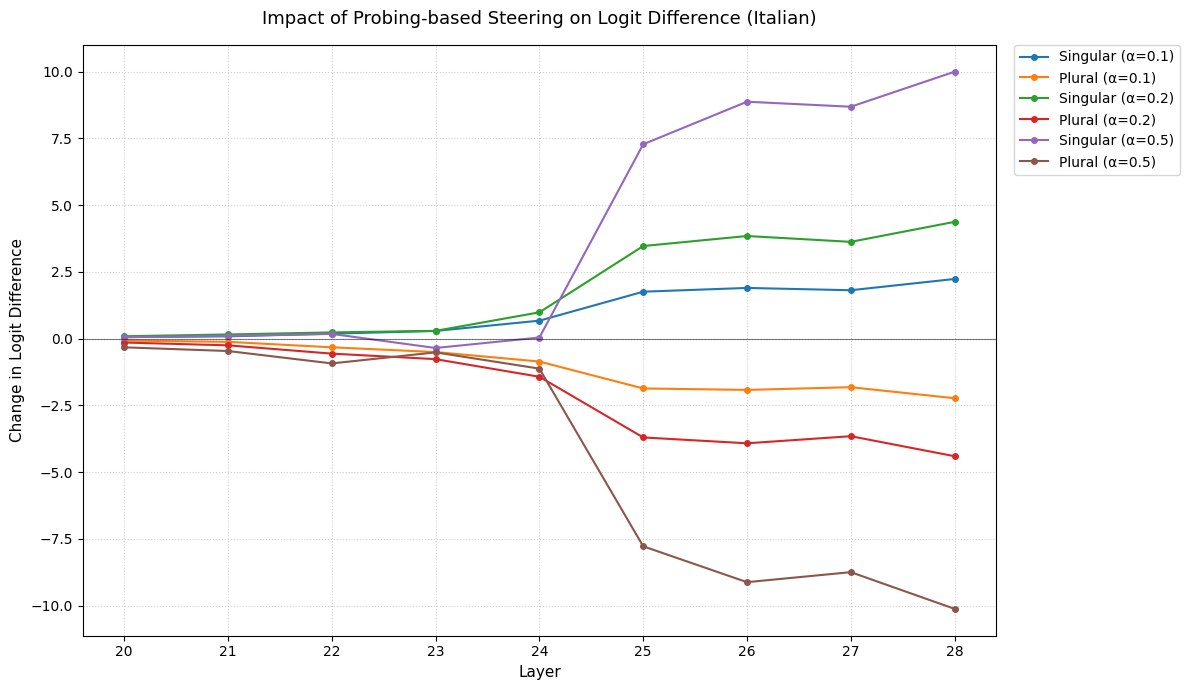

In [30]:
plot_linear_steering(it_grid, 'Italian')

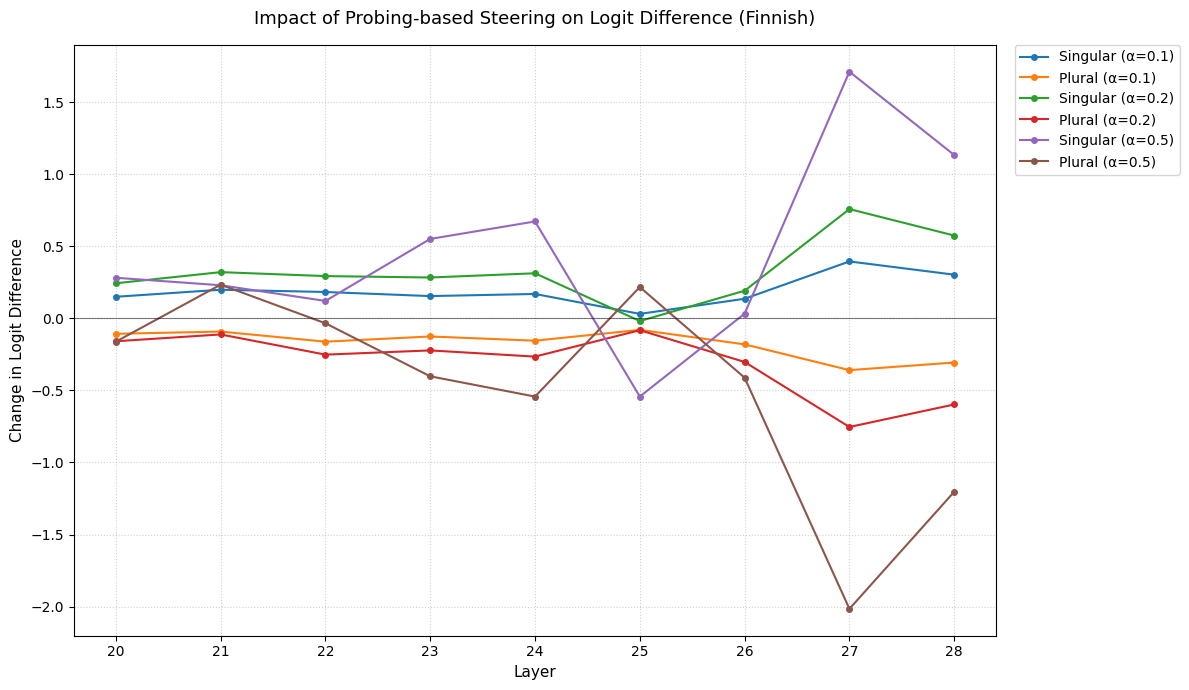

In [31]:
plot_linear_steering(fi_grid, 'Finnish')

In [56]:
def plot_pca_comparison(it_intervention, fi_intervention, it_batches, fi_batches, layer):
    it_acts, it_labels = it_intervention.collect_activations(it_batches, extract_subj, get_subject_indices)
    fi_acts, fi_labels = fi_intervention.collect_activations(fi_batches, extract_subj, get_subject_indices)
    
    all_acts = np.concatenate([it_acts, fi_acts])
    pca = PCA(n_components=2)
    coords = pca.fit_transform(all_acts)
    var_ratio = pca.explained_variance_ratio_
    
    it_coords = coords[:len(it_acts)]
    fi_coords = coords[len(it_acts):]
    
    plt.figure(figsize=(10, 7))
    
    plt.scatter(it_coords[it_labels==1, 0], it_coords[it_labels==1, 1], c='royalblue', label='IT Sing', alpha=0.6)
    plt.scatter(it_coords[it_labels==0, 0], it_coords[it_labels==0, 1], c='navy', label='IT Plur', alpha=0.6)
    
    plt.scatter(fi_coords[fi_labels==1, 0], fi_coords[fi_labels==1, 1], c='lightcoral', label='FI Sing', alpha=0.6)
    plt.scatter(fi_coords[fi_labels==0, 0], fi_coords[fi_labels==0, 1], c='darkred', label='FI Plur', alpha=0.6)
    
    plt.title(f"PCA of Residual Stream Activations (Layer {layer+1})\nPC1: {var_ratio[0]:.2%}, PC2: {var_ratio[1]:.2%}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

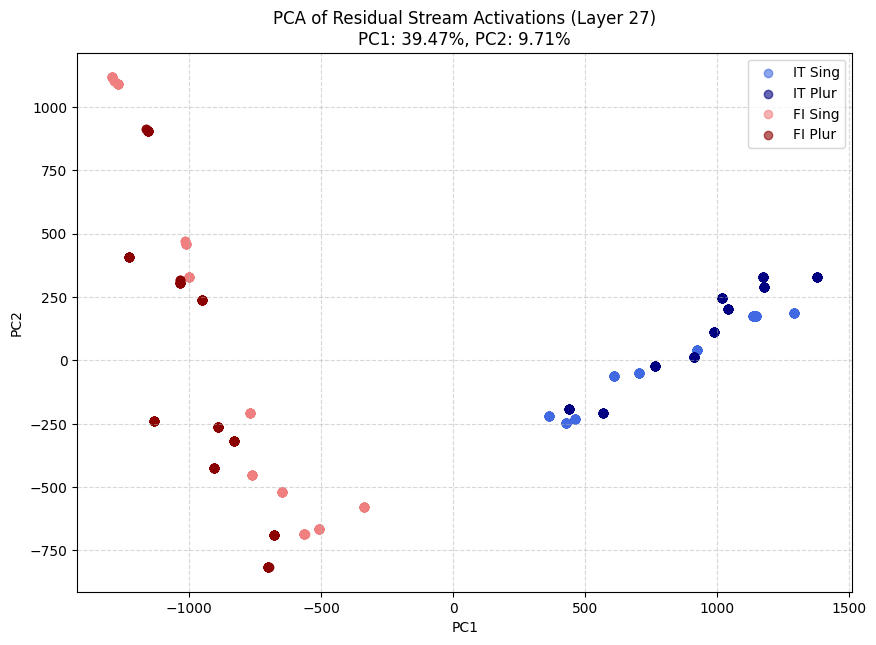

In [57]:
plot_pca_comparison(it_interventions[26], fi_interventions[26], it_test_batches, fi_test_batches, 26)

In [58]:
def plot_single_lang_pca(intervention, batches, lang_name, layer):
    acts, labels = intervention.collect_activations(batches, extract_subj, get_subject_indices)
    
    pca = PCA(n_components=2)
    coords = pca.fit_transform(acts)
    var_ratio = pca.explained_variance_ratio_
    
    plt.figure(figsize=(8, 6))
    plt.scatter(coords[labels==1, 0], coords[labels==1, 1], c='dodgerblue', label='Singular', alpha=0.7)
    plt.scatter(coords[labels==0, 0], coords[labels==0, 1], c='crimson', label='Plural', alpha=0.7)
    
    plt.title(f"PCA {lang_name} (Layer {layer+1})\nPC1: {var_ratio[0]:.2%}, PC2: {var_ratio[1]:.2%}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

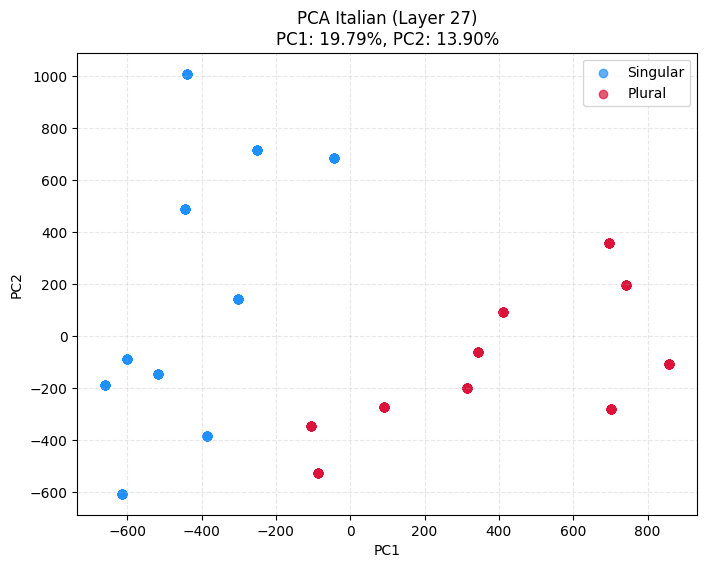

In [64]:
plot_single_lang_pca(it_interventions[26], it_test_batches, "Italian", 26)

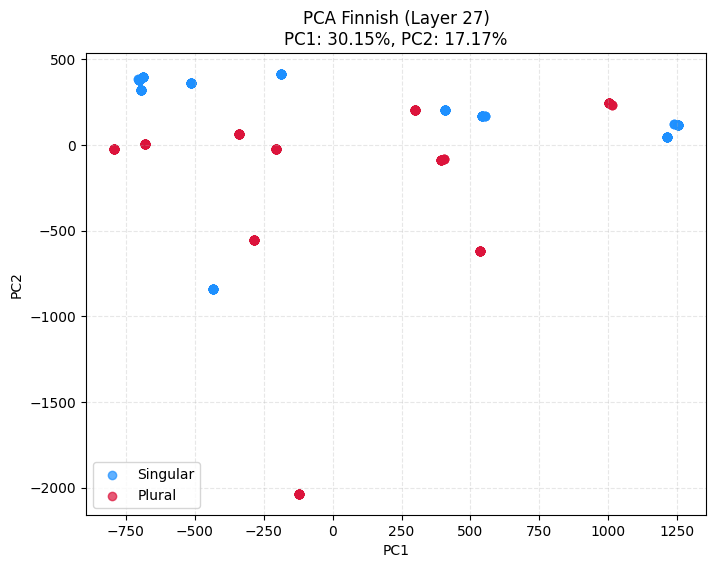

In [65]:
plot_single_lang_pca(fi_interventions[26], fi_test_batches, "Finnish", 26)

In [42]:
def calculate_cosine_similarity(intervention_a, intervention_b):
    """
    Calculates cosine similarity between learned vectors of different languages
    """
    v_it = intervention_a.direction.flatten()
    v_fi = intervention_b.direction.flatten()

    similarity = torch.dot(v_it, v_fi).item()
        
    return similarity

In [43]:
cosine_similarity_comparison = []
for layer in it_layers:
    sim = calculate_cosine_similarity(it_interventions[layer], fi_interventions[layer])
    cosine_similarity_comparison.append({'layer': layer+1, 'similarity': sim})

In [44]:
cosine_similarity_comparison

[{'layer': 20, 'similarity': 0.15373724699020386},
 {'layer': 21, 'similarity': 0.1351897120475769},
 {'layer': 22, 'similarity': 0.1705116629600525},
 {'layer': 23, 'similarity': 0.13651245832443237},
 {'layer': 24, 'similarity': 0.12676092982292175},
 {'layer': 25, 'similarity': 0.1485350877046585},
 {'layer': 26, 'similarity': 0.08929518610239029},
 {'layer': 27, 'similarity': 0.0680341124534607},
 {'layer': 28, 'similarity': 0.044867806136608124}]

## Cross-lingual Probing

In [84]:
def run_cross_lingual_probing(interventions_a, interventions_b, batches_a, batches_b, layers, name_a=None, name_b=None):
    """
    Runs cross-lingual probing for classifiers
    """
    results = []

    for l in layers:
        acts_a, labels_a = interventions_a[l].collect_activations(batches_a, extract_subj, get_subject_indices)
        acts_b, labels_b = interventions_b[l].collect_activations(batches_b, extract_subj, get_subject_indices)

        b_scaled_by_a = interventions_a[l].scaler.transform(acts_b)
        acc_a_on_b = interventions_a[l].clf.score(b_scaled_by_a, labels_b)

        a_scaled_by_b = interventions_b[l].scaler.transform(acts_a)
        acc_b_on_a = interventions_b[l].clf.score(a_scaled_by_b, labels_a)

        # baseline
        native_a = interventions_a[l].clf.score(interventions_a[l].scaler.transform(acts_a), labels_a)
        native_b = interventions_b[l].clf.score(interventions_b[l].scaler.transform(acts_b), labels_b)

        results.append({
            'layer': l + 1,
            'native_a': native_a,
            'native_b': native_b,
            'a_on_b': acc_a_on_b,
            'b_on_a': acc_b_on_a
        })

    print(f"{'Layer':<6} | {name_a + ' Nat':<10} | {name_b + ' Nat':<10} | {name_a + ' -> ' + name_b:<10} | {name_b + ' -> ' + name_a:<10}")
    print("-" * 65)
    for r in results:
        print(f"{r['layer']:<6} | {r['native_a']:<10.3f} | {r['native_b']:<10.3f} | {r['a_on_b']:<10.3f} | {r['b_on_a']:<10.3f}")
    
    return results

In [85]:
layers = list(range(19, 28))

it_fi_results = run_cross_lingual_probing(
    it_interventions, fi_interventions, 
    it_test_batches, fi_test_batches, 
    layers, 'IT', 'FI'
)

Layer  | IT Nat     | FI Nat     | IT -> FI   | FI -> IT  
-----------------------------------------------------------------
20     | 1.000      | 1.000      | 0.615      | 0.500     
21     | 1.000      | 1.000      | 0.419      | 0.500     
22     | 1.000      | 1.000      | 0.615      | 0.500     
23     | 1.000      | 1.000      | 0.598      | 0.500     
24     | 1.000      | 1.000      | 0.562      | 0.500     
25     | 1.000      | 1.000      | 0.652      | 0.500     
26     | 1.000      | 1.000      | 0.615      | 0.500     
27     | 1.000      | 1.000      | 0.517      | 0.500     
28     | 1.000      | 1.000      | 0.354      | 0.500     


## Cross-lingual Probing

In [60]:
class CrossLingualPatching:
    def __init__(self, model):
        self.model = model
        self.n_layers = model.cfg.n_layers

    def run_layer_patching(self, source_clean_b, target_clean_b, target_corr_b, layers_to_patch):
        layer_results = []
        
        with torch.no_grad():
            clean_logits = self.model(target_clean_b['prefix_tokens'])
            corr_logits = self.model(target_corr_b['prefix_tokens'])
            
            clean_ld = get_logit_diff(clean_logits, target_clean_b['answer_token_lists']).item()
            corr_ld = get_logit_diff(corr_logits, target_clean_b['answer_token_lists']).item()
            denom = clean_ld - corr_ld

            _, source_cache = self.model.run_with_cache(
                source_clean_b['prefix_tokens'], 
                names_filter=lambda x: "hook_resid_pre" in x
            )

        for layer in layers_to_patch:
            hook_name = f"blocks.{layer}.hook_resid_pre"
            
            def patch_to_verb_hook(act, hook):
                for b_idx in range(act.shape[0]):
                    src_meta = source_clean_b['metadata'][b_idx]
                    c_indices = get_subject_indices(
                        self.model, src_meta['prefix'], extract_subj(src_meta)
                    )
                    
                    if c_indices:
                        act[b_idx, -1, :] = source_cache[hook_name][b_idx, c_indices[-1], :]
                return act

            patched_logits = self.model.run_with_hooks(
                target_corr_b['prefix_tokens'],
                fwd_hooks=[(hook_name, patch_to_verb_hook)]
            )
            
            val = get_logit_diff(patched_logits, target_clean_b['answer_token_lists']).item()
            
            norm_score = (val - corr_ld) / denom if abs(denom) > 1e-6 else 0.0
            layer_results.append(norm_score)
            
        return layer_results

    def process_batches(self, source_clean_batches, target_clean_batches, target_corr_batches, layers_to_patch: list):
        all_layer_scores = []
        
        for i in range(len(source_clean_batches)):
            print(f"Processing Batch {i+1}/{len(source_clean_batches)}...")
            
            scores = self.run_layer_patching(
                source_clean_batches[i], 
                target_clean_batches[i], 
                target_corr_batches[i],
                layers_to_patch
            )
            all_layer_scores.append(scores)
            
        return np.mean(all_layer_scores, axis=0)

In [61]:
patcher = CrossLingualPatching(model)

In [69]:
layers = list(range(19, 28))

it_to_fi_results = patcher.process_batches(
    it_clean_batches[:37], 
    fi_clean_batches[:37], 
    fi_corr_batches[:37], 
    layers
)

Processing Batch 1/37...
Processing Batch 2/37...
Processing Batch 3/37...
Processing Batch 4/37...
Processing Batch 5/37...
Processing Batch 6/37...
Processing Batch 7/37...
Processing Batch 8/37...
Processing Batch 9/37...
Processing Batch 10/37...
Processing Batch 11/37...
Processing Batch 12/37...
Processing Batch 13/37...
Processing Batch 14/37...
Processing Batch 15/37...
Processing Batch 16/37...
Processing Batch 17/37...
Processing Batch 18/37...
Processing Batch 19/37...
Processing Batch 20/37...
Processing Batch 21/37...
Processing Batch 22/37...
Processing Batch 23/37...
Processing Batch 24/37...
Processing Batch 25/37...
Processing Batch 26/37...
Processing Batch 27/37...
Processing Batch 28/37...
Processing Batch 29/37...
Processing Batch 30/37...
Processing Batch 31/37...
Processing Batch 32/37...
Processing Batch 33/37...
Processing Batch 34/37...
Processing Batch 35/37...
Processing Batch 36/37...
Processing Batch 37/37...


In [70]:
it_to_fi_results

array([0.54449244, 0.49997985, 0.5217638 , 0.48746987, 0.45761493,
       0.43555431, 0.44382348, 0.46082971, 0.43067551])

In [72]:
layers = list(range(19, 28))

fi_to_it_results = patcher.process_batches(
    fi_clean_batches[:37], 
    it_clean_batches[:37], 
    it_corr_batches[:37], 
    layers
)

Processing Batch 1/37...
Processing Batch 2/37...
Processing Batch 3/37...
Processing Batch 4/37...
Processing Batch 5/37...
Processing Batch 6/37...
Processing Batch 7/37...
Processing Batch 8/37...
Processing Batch 9/37...
Processing Batch 10/37...
Processing Batch 11/37...
Processing Batch 12/37...
Processing Batch 13/37...
Processing Batch 14/37...
Processing Batch 15/37...
Processing Batch 16/37...
Processing Batch 17/37...
Processing Batch 18/37...
Processing Batch 19/37...
Processing Batch 20/37...
Processing Batch 21/37...
Processing Batch 22/37...
Processing Batch 23/37...
Processing Batch 24/37...
Processing Batch 25/37...
Processing Batch 26/37...
Processing Batch 27/37...
Processing Batch 28/37...
Processing Batch 29/37...
Processing Batch 30/37...
Processing Batch 31/37...
Processing Batch 32/37...
Processing Batch 33/37...
Processing Batch 34/37...
Processing Batch 35/37...
Processing Batch 36/37...
Processing Batch 37/37...


In [76]:
fi_to_it_results

array([ 0.03057155, -0.06254411, -0.01992063, -0.05630691, -0.06816773,
       -0.12438847, -0.04764338,  0.19081729,  0.18805588])

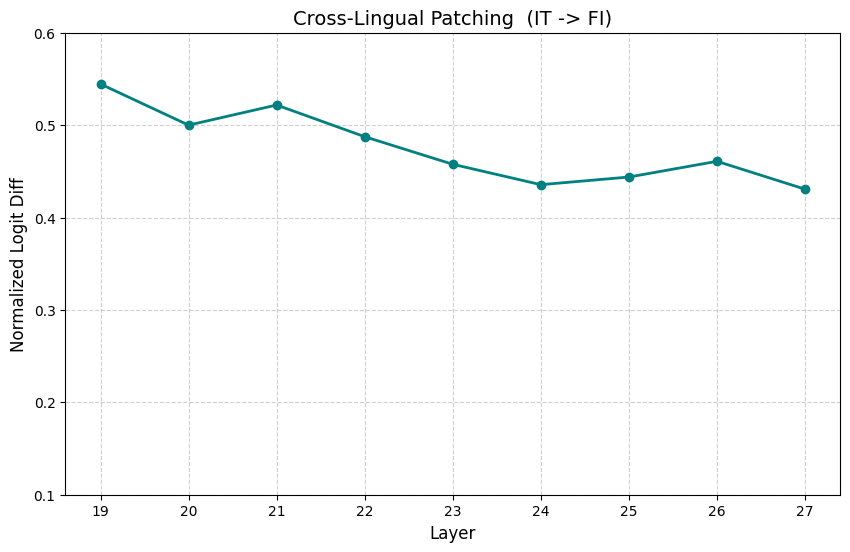

In [74]:
layers = list(range(19, 28))

plt.figure(figsize=(10, 6))
plt.plot(layers, it_to_fi_results, marker='o', linestyle='-', color='teal', linewidth=2)

plt.title('Cross-Lingual Patching  (IT -> FI)', fontsize=14)
plt.xlabel('Layer', fontsize=12)
plt.ylabel('Normalized Logit Diff', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0.1, 0.6)
plt.xticks(layers)

plt.show()

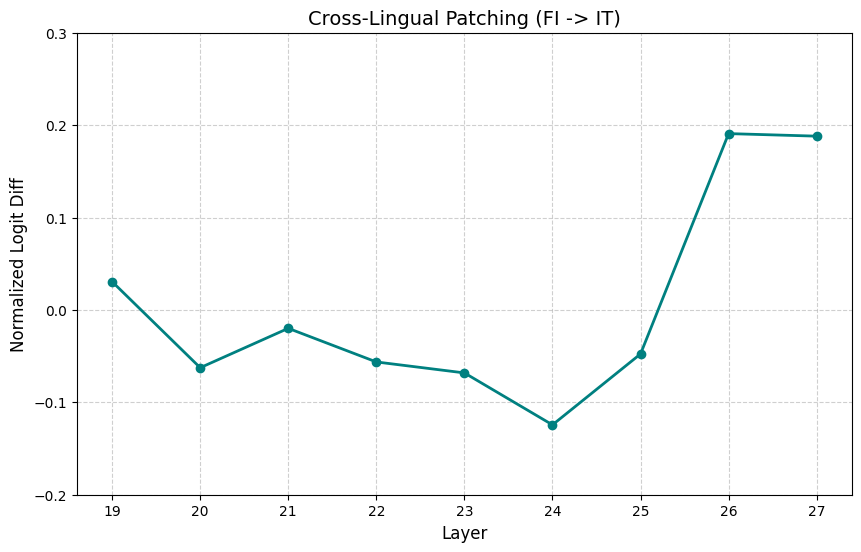

In [75]:
layers = list(range(19, 28))

plt.figure(figsize=(10, 6))
plt.plot(layers, fi_to_it_results, marker='o', linestyle='-', color='teal', linewidth=2)

plt.title('Cross-Lingual Patching (FI -> IT)', fontsize=14)
plt.xlabel('Layer', fontsize=12)
plt.ylabel('Normalized Logit Diff', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-0.2, 0.3)
plt.xticks(layers)

plt.show()